In [2]:
import pandas as pd 
rfm = pd.read_csv(r"C:\Users\acer\Downloads\GitHub\python-program\notebooks\rfm_features.csv")
user_df = pd.read_csv("users.csv")
print(rfm.head())
rfm = rfm.merge(user_df[['user_id','city']], on='user_id', how='left')
print(rfm.columns)
tier1_cities = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata']

rfm['city_tier'] = rfm['city'].apply(
    lambda x: 'Tier 1' if x in tier1_cities else 'Tier 2/3'
)
print(type(rfm))

    user_id  Recency  Frequency  Monetary  Avg_Txn_Value  Weekend_Ratio  \
0  USR00001        9         11  10597.11     963.373636       0.363636   
1  USR00002       57          7   3444.34     492.048571       0.285714   
2  USR00003       76          8   3195.66     399.457500       0.500000   
3  USR00004       14         10   2706.06     270.606000       0.000000   
4  USR00005       43          8   8672.13    1084.016250       0.250000   

   Night_Ratio  user_loyalty_score  
0     0.545455            5304.055  
1     0.285714            1725.670  
2     0.000000            1601.830  
3     0.100000            1358.030  
4     0.250000            4340.065  
Index(['user_id', 'Recency', 'Frequency', 'Monetary', 'Avg_Txn_Value',
       'Weekend_Ratio', 'Night_Ratio', 'user_loyalty_score', 'city'],
      dtype='str')
<class 'pandas.DataFrame'>


In [3]:
from sklearn.preprocessing import StandardScaler

features = ['Recency','Frequency','Monetary',
            'Avg_Txn_Value','Weekend_Ratio','Night_Ratio']

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

Elbow + Silhoutte

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

    print(f"K={k}, Inertia={km.inertia_:.1f}, Silhouette={silhouette_score(rfm_scaled, labels):.4f}")

K=2, Inertia=9639.5, Silhouette=0.2674
K=3, Inertia=8296.6, Silhouette=0.1711
K=4, Inertia=7396.4, Silhouette=0.1641
K=5, Inertia=6627.9, Silhouette=0.1695
K=6, Inertia=6018.9, Silhouette=0.1747
K=7, Inertia=5601.3, Silhouette=0.1737
K=8, Inertia=5386.4, Silhouette=0.1481


plot chart

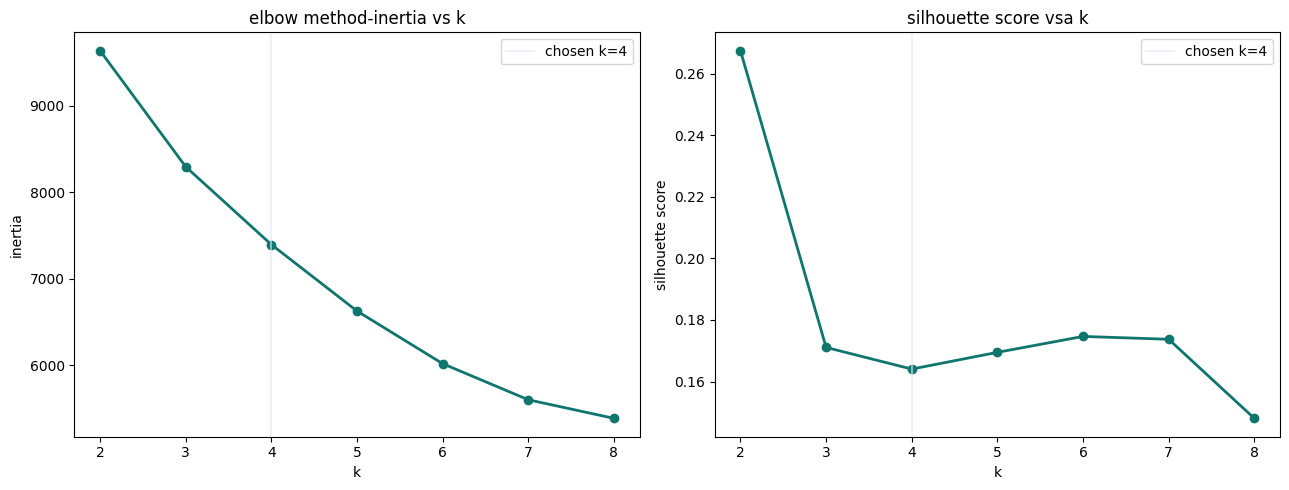

In [5]:
import matplotlib.pyplot as plt 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range),inertias,marker='o',color='#0f766e',linewidth=2)
axes[0].axvline(x=4,color='lavender',linestyle='-',alpha=0.6,label='chosen k=4')
axes[0].set_title('elbow method-inertia vs k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')
axes[0].legend()

axes[1].plot(list(k_range),silhouettes,marker='o',color='#0f766e',linewidth=2)
axes[1].axvline(x=4,color='lavender',linestyle='-',alpha=0.6,label='chosen k=4')
axes[1].set_title('silhouette score vsa k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette score')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()


cluster distribution

In [6]:

rfm['Cluster'] = km.fit_predict(rfm_scaled)

print("Cluster Distribution:")
print(rfm['Cluster'].value_counts().sort_index())

print("\nSilhouette Score:")
print(silhouette_score(rfm_scaled, rfm['Cluster']))

Cluster Distribution:
Cluster
0    189
1    219
2     65
3    305
4    356
5    321
6    278
7    267
Name: count, dtype: int64

Silhouette Score:
0.14805462300455563


cluster profile

In [7]:
profile = rfm.groupby('Cluster').agg(
    Recency=('Recency', 'median'),
    Frequency=('Frequency', 'median'),
    Monetary=('Monetary', 'median'),
    Avg_Txn_Value=('Avg_Txn_Value', 'median'),
    Weekend_Ratio=('Weekend_Ratio', 'median'),
    Night_Ratio=('Night_Ratio', 'median')
).round(2)

print(profile)

         Recency  Frequency  Monetary  Avg_Txn_Value  Weekend_Ratio  \
Cluster                                                               
0          106.0        8.0   4646.99         588.49           0.25   
1           15.0       15.0  10316.00         691.18           0.31   
2           20.0       11.0  32660.45        2893.71           0.25   
3           25.0        9.0   5298.35         614.74           0.25   
4           15.0       12.0   6070.59         521.86           0.21   
5           25.0        9.0   4774.95         538.39           0.45   
6           27.5        7.0   3465.10         496.12           0.17   
7           23.0       10.0  17535.57        1692.38           0.29   

         Night_Ratio  
Cluster               
0               0.33  
1               0.33  
2               0.33  
3               0.50  
4               0.30  
5               0.30  
6               0.17  
7               0.30  


segments

In [8]:
segment_names = {
    0: "Regular Users",
    1: "Dormant Users",
    2: "Power Users",
    3: "Active Rising Users"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm[["Cluster", "Segment"]].head()

,Cluster,Segment
0,3,Active Rising Users
1,6,NaN
2,5,NaN
3,6,NaN
4,6,NaN


cluster heatmap

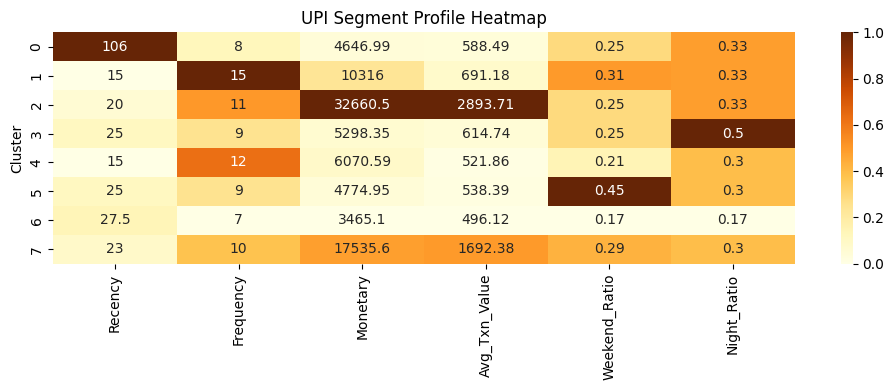

In [9]:
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

heat_data = profile.copy()



mms = MinMaxScaler()

heat_norm = pd.DataFrame(
    mms.fit_transform(heat_data),
    columns=heat_data.columns,
    index=heat_data.index
)

plt.figure(figsize=(10,4))
sns.heatmap(
    heat_norm,
    annot=heat_data,
    fmt='g',
    cmap='YlOrBr'
)

plt.title("UPI Segment Profile Heatmap")
plt.tight_layout()
plt.savefig('outputs/heatmap_segment.png')
plt.show()

pca scatter plot

PC1 Variance: 32.65949856927442
PC2 Variance: 21.074620731082614


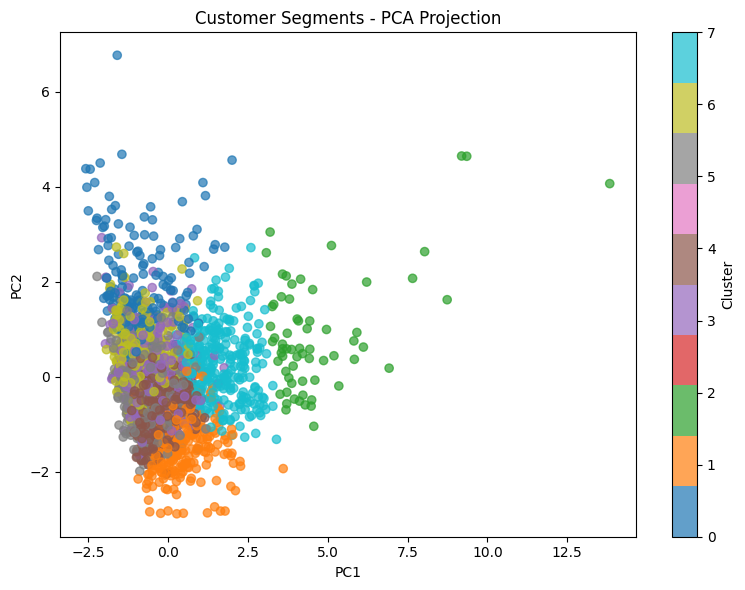

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)

components = pca.fit_transform(rfm_scaled)

print("PC1 Variance:", pca.explained_variance_ratio_[0]*100)
print("PC2 Variance:", pca.explained_variance_ratio_[1]*100)

plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1],
    c=labels,
    cmap='tab10',
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments - PCA Projection")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.savefig('outputs/pca_scatter.png')
plt.show()

revenue and user count segment

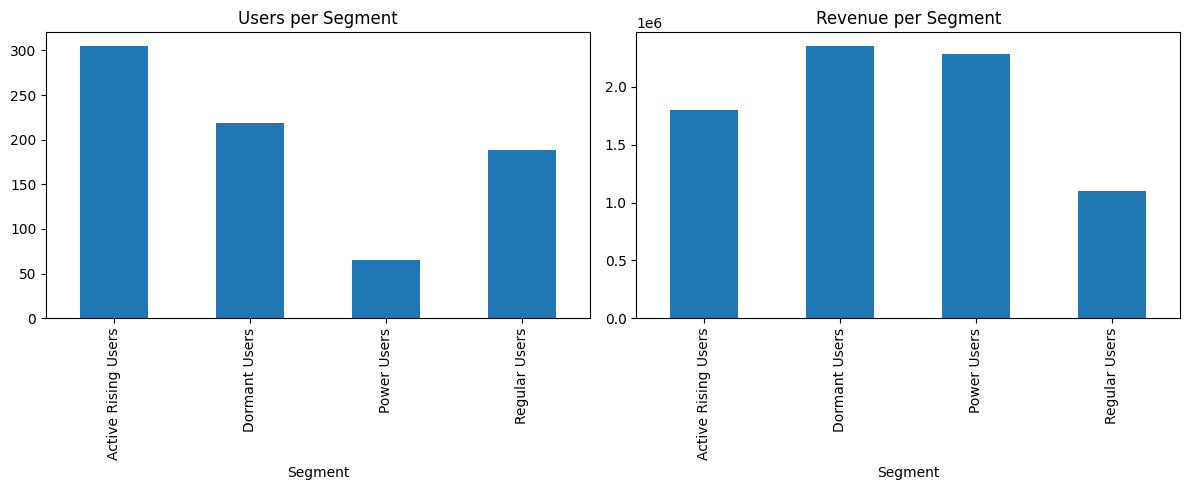

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

rfm.groupby('Segment').size().plot(
    kind='bar',
    ax=axes[0],
    title='Users per Segment'
)

rfm.groupby('Segment')['Monetary'].sum().plot(
    kind='bar',
    ax=axes[1],
    title='Revenue per Segment'
)

plt.tight_layout()
plt.savefig('outputs/revenue_users_per_segment.png')
plt.show()

city tier segment

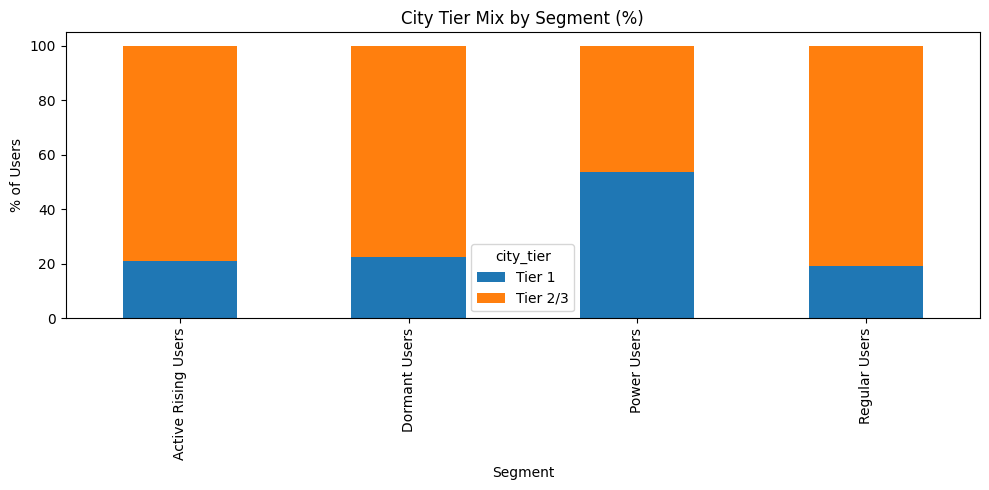

In [36]:
city_seg = rfm.groupby(['Segment', 'city_tier']).size().unstack(fill_value=0)

city_pct = city_seg.div(city_seg.sum(axis=1), axis=0) * 100

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,5))

city_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

ax.set_title("City Tier Mix by Segment (%)")
ax.set_ylabel("% of Users")
ax.set_xlabel("Segment")

plt.tight_layout()
plt.savefig('outputs/city_tier_by_segment.png')
plt.show()

In [13]:
rfm.to_csv("rfm_segmented.csv", index=False)

print("File saved successfully")
print(rfm.shape)

File saved successfully
(2000, 12)


week 3 summary

output produced:
- Created RFM features
- Applied StandardScaler
- Used K-Means clustering
- Identified 4 customer segments
- Generated visualizations


Surprising Result:
        A small group of customers contributed a large portion of transaction value, showing the importance of retaining high-value customers.

Limitation:
        Only RFM features were used. Additional customer behavior features could improve segmentation.

Week 4 Plan:
- Build final presentation
- Create business recommendations
- Prepare project report
- Validate segment strategies
